# 1. Introduction
-   **Weights & Biases Link:** [TODO: Link to my W&B report](https://wandb.ai/janis-kneubuehler-hochschule-luzern/janis-kneubuehler-nlp-project1/reports/I-BA_NLP-F2601-PIQA-Project-One--VmlldzoxNjM4MzI0MQ?accessToken=v75fk8fg8uj10657kmkivjcfcgrco9imi4h12vbhq6nm4unch0l2am3y92v9p05h)
-   **Tools & Sources Used:**
    - AI Tools
        - NotebookLM: Summarizing course materials and project description, Creating Template of Python Notebook with titles and descriptions
        - Gemini: Coding support / Learning help
        - Claude: Coding support
    - Others
        - Deepl: Translation 
        - PyTorch documentation
        - Course documents
        - Medium articles (important ones are in the specific markdown cells)


# 2. Setup & Data Loading
I used libraries that were covered in the course. I didn't evaluate different libraries.<br>I chose the ones with the biggest community in web.
Seed: I've also added the seed to the random library, because i wasn't sure if it is used by any other libraries as a sublibrary. Just to be on the safe side.

In [ ]:
# !pip install datasets gensim wandb nltk torch transformers

In [35]:
from transformers import DistilBertTokenizerFast
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

import torch
from datasets import load_dataset
import wandb
import numpy as np
import random

In [36]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [39]:
# Load the PIQA dataset from revision because dataset scripts are no longer supported
# Use splits like specified in Course Project Slides
train = load_dataset('ybisk/piqa', split='train[:-1000]', revision='refs/convert/parquet')
valid = load_dataset('ybisk/piqa', split='train[-1000:]', revision='refs/convert/parquet')
test = load_dataset('ybisk/piqa', split='validation', revision='refs/convert/parquet')

In [25]:
print(train)
print(f"Example: {train[0]}")

Dataset({
    features: ['goal', 'sol1', 'sol2', 'label'],
    num_rows: 15113
})
Example: {'goal': "When boiling butter, when it's ready, you can", 'sol1': 'Pour it onto a plate', 'sol2': 'Pour it into a jar', 'label': 1}


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (552 > 512). Running this sequence through the model will result in indexing errors


99% of the dataset has fewer than 125 tokens. Max length is 552


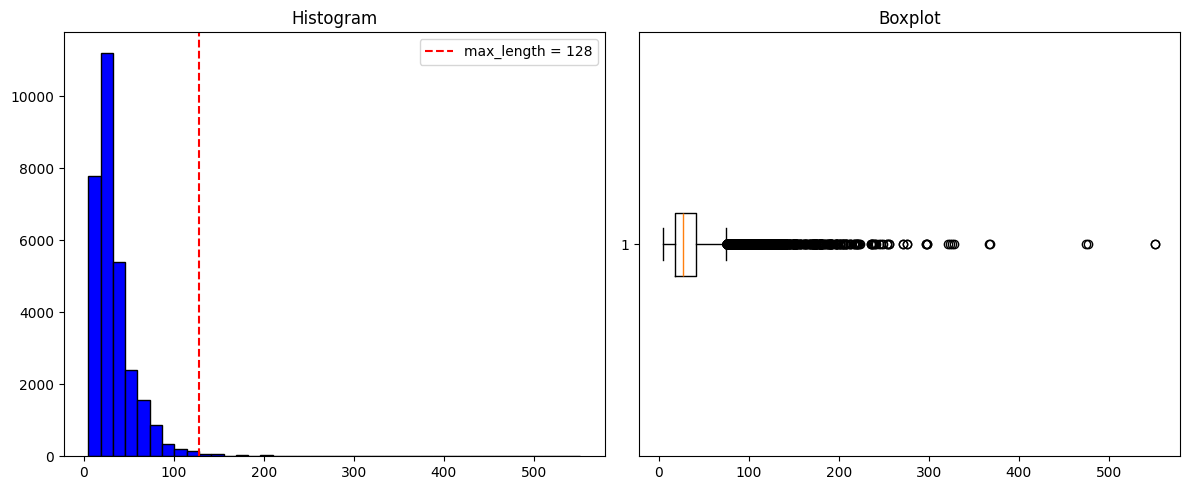

In [ ]:
import matplotlib.pyplot as plt

# Analysing Data Distribution

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
lengths = [len(tokenizer(ex["goal"] + " " + ex["sol1"])["input_ids"]) for ex in train]
lengths += [len(tokenizer(ex["goal"] + " " + ex["sol2"])["input_ids"]) for ex in train]
print(f"99% of the dataset has fewer than {np.percentile(lengths, 99):.0f} tokens. Max length is {max(lengths)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(lengths, bins=40, color='blue', edgecolor='black')
ax1.axvline(128, color='red', linestyle='dashed', label='max_length = 128')
ax1.set_title('Histogram')
ax1.legend()

ax2.boxplot(lengths, vert=False) 
ax2.set_title('Boxplot')

plt.tight_layout()
plt.show()

# 3. Preprocessing
**Truncation:**
Unlike in Project 1, I chose truncation of max lenght of 128 in this Project. <br>Based on data distribution (see above) with over 99% under 128 It's a compromise I'm willing to make to save processing power and avoiding Out Of Memory error. (quadratic scaling in Transformers) <br>I implemented again dynamic padding (pad to max length within a batch), because most batches will not need 128 tokens.
**Text Transformation:**
I do not manually remove stoppwords, stemming and no lowercasing. BERT expects natural texts and was trained on such texts. <br>Transformation needed by BERT will be done by DistilBertTokenizerFast (e.g. do_lower_case: bool = True). 
**Text Format**
Same as in Project 1: I concatenate the goal with both solution and a separator, so from one row i get two: goal + solution1 and goal + solution2. <br>The tokenizer automatically inserts the correct special tokens, generating the [CLS] goal [SEP] solution [SEP] format. <br>This built-in feature explicitly signals to the model where the context ends and the solution begins, perfectly preventing the two sentences from blending together without any manual formatting.

In [40]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print(f"pad token: {tokenizer.pad_token_id}")
MAX_LEN = 128  # see reason above

def preprocess(example):
    example1 = tokenizer(
        example['goal'], example['sol1'],
        max_length=MAX_LEN,
        truncation=True,
        padding=False, # dynamic padding in collate_fn
    )
    example2 = tokenizer(
        example['goal'], example['sol2'],
        max_length=MAX_LEN,
        truncation=True,
        padding=False, # dynamic padding in collate_fn
    )
    return {
        'input_ids_1':      example1['input_ids'],
        'attention_mask_1': example1['attention_mask'],
        'input_ids_2':      example2['input_ids'],
        'attention_mask_2': example2['attention_mask'],
        'label':            example['label'],
    }

train = train.map(preprocess, remove_columns=['goal', 'sol1', 'sol2'])
valid = valid.map(preprocess, remove_columns=['goal', 'sol1', 'sol2'])
test  = test.map(preprocess,  remove_columns=['goal', 'sol1', 'sol2'])

train.set_format('torch') # TODO: Research better
valid.set_format('torch')
test.set_format('torch')

# Check how many were truncated
all_lens = [len(x) for x in train['input_ids_1']] + [len(x) for x in train['input_ids_2']]
print(f"Truncated sequences: {sum(1 for l in all_lens if l == MAX_LEN)} from total sequences: {len(all_lens)}")

def collate_fn(batch):
    pad_id = tokenizer.pad_token_id

    input_ids_1      = pad_sequence([x['input_ids_1']      for x in batch], batch_first=True, padding_value=pad_id)
    attention_mask_1 = pad_sequence([x['attention_mask_1'] for x in batch], batch_first=True, padding_value=0)
    input_ids_2      = pad_sequence([x['input_ids_2']      for x in batch], batch_first=True, padding_value=pad_id)
    attention_mask_2 = pad_sequence([x['attention_mask_2'] for x in batch], batch_first=True, padding_value=0)
    labels           = torch.stack([x['label'] for x in batch])

    return {
        'input_ids_1':      input_ids_1,
        'attention_mask_1': attention_mask_1,
        'input_ids_2':      input_ids_2,
        'attention_mask_2': attention_mask_2,
        'labels':           labels,
    }

BATCH_SIZE = 32

train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

batch = next(iter(train_loader))
print("input_ids_1 shape:      ", batch['input_ids_1'].shape)
print("attention_mask_1 shape: ", batch['attention_mask_1'].shape)
print("labels shape:           ", batch['labels'].shape)

print("\nSample decoded input 1:")
print(tokenizer.decode(batch['input_ids_1'][0]))
print(tokenizer.decode(batch['attention_mask_1'][0]))
print(tokenizer.decode(batch['input_ids_2'][0]))
print(tokenizer.decode(batch['attention_mask_2'][0]))

pad token: 0
Truncated sequences: 289 from total sequences: 30226
input_ids_1 shape:       torch.Size([32, 66])
attention_mask_1 shape:  torch.Size([32, 66])
labels shape:            torch.Size([32])

Sample decoded input 1:
[CLS] fingers [SEP] can pinch cheeks. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
[unused0] [unused0] [unused0] [unused0] [unused0] [unused0] [unused0] [unused0] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PA

# 4. Model Definition
**Decisions:**
For my Transformer models, I chose distilbert-base-uncased. Standard BERT has an advantage here because its token_type_ids help the model tell the difference between the two parts of goal and the solution. Even though DistilBERT misses this feature and only uses the [SEP] token, I chose it because the faster training time and lower memory usage are more important for my setup.

In [42]:
from transformers import DistilBertConfig, DistilBertModel, DistilBertTokenizerFast
import torch
import torch.nn as nn

class PIQATransformer(nn.Module):
    """
    Wraps a DistilBERT encoder with a classification head for PIQA.
    Used for BOTH Model 1 (random init) and Model 2 (pretrained).
    The only difference is which bert_model you pass in.
    """
    def __init__(self, bert_model, hidden_size=768, dropout_rate=0.1):
        super().__init__()
        self.bert = bert_model

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_size // 2, 1),   # single score per pair
        )

    def _encode(self, input_ids, attention_mask):
        """Run DistilBERT and return the [CLS] token representation."""
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = output.last_hidden_state[:, 0, :]  # take [CLS] = position 0
        return cls_token

    def forward(self, input_ids_1, attention_mask_1,input_ids_2, attention_mask_2):
        score1 = self.classifier(self._encode(input_ids_1, attention_mask_1))  # (B, 1)
        score2 = self.classifier(self._encode(input_ids_2, attention_mask_2))  # (B, 1)

        logits = torch.cat([score1, score2], dim=1)  # (B, 2)
        return logits

# Model 1 - randomly initialized weights, but DistilBERT architecture
def get_model1():
    config = DistilBertConfig.from_pretrained('distilbert-base-uncased')
    random_bert = DistilBertModel(config)

    model1 = PIQATransformer(random_bert, hidden_size=config.hidden_size, dropout_rate=0.1)
    print(f"Model 1 parameters: {sum(p.numel() for p in model1.parameters()):,}")
    return model1

# Model 2 - DistilBERT with pretrained weights
def get_model2():
    pretrained_bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

    model2 = PIQATransformer(pretrained_bert, hidden_size=pretrained_bert.config.hidden_size, dropout_rate=0.1)
    print(f"Model 2 parameters: {sum(p.numel() for p in model2.parameters()):,}")
    return model2

# 5. Training
**Decissions / Clarification:**
- get_linear_schedule_with_warmup

In [43]:
import os
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import wandb

def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        # Push batch components to target device
        input_ids_1      = batch['input_ids_1'].to(device)
        attention_mask_1 = batch['attention_mask_1'].to(device)
        input_ids_2      = batch['input_ids_2'].to(device)
        attention_mask_2 = batch['attention_mask_2'].to(device)
        labels           = batch['labels'].to(device)

        optimizer.zero_grad()
        
        # Forward pass through our custom PIQATransformer
        logits = model(input_ids_1, attention_mask_1, input_ids_2, attention_mask_2)
        loss   = criterion(logits, labels)
        
        # Backward pass & safety gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()  # Update the learning rate step-by-step

        # Metrics accumulation
        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # Strict evaluation hygiene: isolate weights from eval gradients
        for batch in loader:
            input_ids_1      = batch['input_ids_1'].to(device)
            attention_mask_1 = batch['attention_mask_1'].to(device)
            input_ids_2      = batch['input_ids_2'].to(device)
            attention_mask_2 = batch['attention_mask_2'].to(device)
            labels           = batch['labels'].to(device)

            logits = model(input_ids_1, attention_mask_1, input_ids_2, attention_mask_2)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


def train_model(model, train_loader, valid_loader, checkpoint_name, 
                lr, epochs, patience, device):
    
    model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Weight decay prevents the Transformer weights from growing uncontrollably
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Calculate training schedule geometry
    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * 0.1)  # Allocate 10% of training time to warming up
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    best_val_acc     = 0.0
    patience_counter = 0
    best_path        = f"best_{checkpoint_name}.pt"
    last_path        = f"last_{checkpoint_name}.pt"

    print(f"Dataset batched into {len(train_loader)} steps per epoch. Beginning training...")

    for epoch in range(epochs):
        # Run step calculations
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
        val_loss, val_acc     = validate(model, valid_loader, criterion, device)

        # Broadcast telemetry to Weights & Biases
        wandb.log({
            "epoch":      epoch + 1,
            "train_loss": train_loss,
            "train_acc":  train_acc,
            "val_loss":   val_loss,
            "val_acc":    val_acc,
            "learning_rate": optimizer.param_groups[0]['lr']  # Track warmup changes live!
        })

        print(f"Epoch {epoch+1:02d}/{epochs:02d} - Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Fallback checkpoint storage
        torch.save(model.state_dict(), last_path)

        # Early Stopping check
        if val_acc > best_val_acc:
            print(f"  🔥 Val Acc improved from {best_val_acc:.4f} to {val_acc:.4f}. Checkpoint cached.")
            best_val_acc     = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_counter += 1
            print(f"  ⏳ No generalization progress. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"  🛑 Early stopping activated after {epoch+1} epochs.")
                break

    # Restore optimal weight configuration before moving to the evaluation section
    if os.path.exists(best_path):
        print(f"\nTraining session complete. Restoring optimal weights from {best_path}")
        model.load_state_dict(torch.load(best_path))
    
    return model

In [45]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Login to W&B
wandb.login()

wandb.init(
    project="janis-kneubuehler-nlp-project2-test", 
    config={
        "architecture": "ArchitectureOne",
        "run_goal": "decrease dropout",
        "learning_rate": 1e-3,
        "hidden_dim": 128,
        "dropout": 0.2,
        "epochs": 2,
        "batch_size": BATCH_SIZE
    }
)

print("🚀 Starting 1-epoch trial run to check entire pipeline infrastructure...")

tested_model = train_model(
    model=get_model2(),                   # Passing your pretrained PIQATransformer
    train_loader=train_loader,     # Dynamic padding train data
    valid_loader=valid_loader,     # Dynamic padding validation data
    checkpoint_name="smoke_test",  # Will save best_smoke_test.pt and last_smoke_test.pt
    lr=2e-5,
    epochs=3,                       # Force exactly 1 epoch for immediate feedback
    patience=1,
    device=device
)

# 4. Terminate the W&B run instance cleanly
wandb.finish()

🚀 Starting 1-epoch trial run to check entire pipeline infrastructure...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6848.40it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model 2 parameters: 66,658,561
Dataset batched into 473 steps per epoch. Beginning training...
Epoch 01/03 - Train Loss: 0.6885 Acc: 0.5221 - Val Loss: 0.6808 Acc: 0.5770
  🔥 Val Acc improved from 0.0000 to 0.5770. Checkpoint cached.
Epoch 02/03 - Train Loss: 0.6516 Acc: 0.6092 - Val Loss: 0.6731 Acc: 0.6060
  🔥 Val Acc improved from 0.5770 to 0.6060. Checkpoint cached.
Epoch 03/03 - Train Loss: 0.5944 Acc: 0.6681 - Val Loss: 0.6947 Acc: 0.6060
  ⏳ No generalization progress. Patience: 1/1
  🛑 Early stopping activated after 3 epochs.

Training session complete. Restoring optimal weights from best_smoke_test.pt


epoch,▁▅█
learning_rate,█▅▁
train_acc,▁▅█
train_loss,█▅▁
val_acc,▁██
val_loss,▃▁█
epoch,3
learning_rate,0
train_acc,0.6681
train_loss,0.5944
val_acc,0.606


# 6. Evaluation
The models evaluated werde renamed manually by myself.
For the evaluation I used the models with the following reasons:
- Architecture 1: "fearless-silence-19" selected for its low validation loss (0.683) after decreasing dropout to 0.2. It safely avoided the overfitting seen in runs with artificially higher peak accuracies.
- Architecture 2: "trim-star-21" selected because it achieved the highest validation accuracy (57.7%) among all Architecture 2 experiments after successfully increasing the batch size to 64.

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss    = 0.0
    correct_preds = 0
    total_preds   = 0

    with torch.no_grad():
        for batch in loader:
            logits = model(batch['input1'], batch['input2'])
            loss   = criterion(logits, batch['labels'])
            total_loss    += loss.item()
            predictions    = torch.argmax(logits, dim=1)
            correct_preds += (predictions == batch['labels']).sum().item()
            total_preds   += batch['labels'].size(0)

    return total_loss / len(loader), correct_preds / total_preds

########################## Architecture 1 ##########################
model.load_state_dict(torch.load("./best_arch1_model.pt")) # My best Model of Arch1

val_loss1,  val_acc1  = evaluate(model, valid_loader, criterion)
test_loss1, test_acc1 = evaluate(model, test_loader,  criterion)
print(f"Architecture 1 – Validation, Loss: {val_loss1:.4f}, Accuracy: {val_acc1:.4f}")
print(f"Architecture 1 – Test, Loss: {test_loss1:.4f}, Accuracy: {test_acc1:.4f}")

########################## Architecture 2 ##########################
model2.load_state_dict(torch.load("./best_arch2_model.pt")) # My best Model of Arch2

val_loss2,  val_acc2  = evaluate(model2, valid_loader, criterion2)
test_loss2, test_acc2 = evaluate(model2, test_loader,  criterion2)
print(f"Architecture 2 – Validation, Loss: {val_loss2:.4f}, Accuracy: {val_acc2:.4f}")
print(f"Architecture 2 – Test, Loss: {test_loss2:.4f}, Accuracy: {test_acc2:.4f}")

Architecture 1 – Validation, Loss: 0.6821, Accuracy: 0.5750
Architecture 1 – Test, Loss: 0.6848, Accuracy: 0.5620
Architecture 2 – Validation, Loss: 0.7025, Accuracy: 0.5780
Architecture 2 – Test, Loss: 0.6924, Accuracy: 0.5773


# 7. Conclusion & Interpretation
**Results Summary:**
Both architectures achieved very similar results on the unseen test set, hovering around 56-57% accuracy. Since there are only two possible answers per question, random guessing would be 50%. While both models learned something, they clearly struggled with the task. The results are not much better than a coin flip.

**Model Comparison:**
Architecture 1: This model was incredibly fast to train. Because the embeddings were frozen, it was highly resistant to overfitting. However, because Mean Pooling blends all words into a single average vector, it loses the word order. Since the model completely ignores the grammatical order of the words, it knows which objects are in the sentence, but has no idea how they interact with each other.

Architecture 2: In my expections this model should be much smarter because the bidirectional LSTM reads the sequence and preserves grammar. However, because I unfroze the embeddings, the model had millions of trainable parameters. The training process was much longer and I had the problem of overfitting. Even with different strategies like high dropout and Weight Decay, it failed to generalize better than the simpler baseline.

**Interpretation:**
The PIQA dataset tests physical commonsense. Word2Vec embeddings only know which words appear next to each other in Web articles. They don't actually understand physical properties. These final results clearly demonstrate that it is extremely difficult for basic text-only models to learn real-world physics purely from the statistical distribution of words.